In [1]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
login(UserSecretsClient().get_secret("HF_TOKEN"))

In [2]:
import json, re
import torch
import pandas as pd
from pathlib import Path
from PIL import Image
from transformers import AutoProcessor, AutoModelForMultimodalLM

# Modele charge UNE seule fois (4B parametres, GPU Kaggle requis)
MODEL_ID = "google/medgemma-4b-it"
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMultimodalLM.from_pretrained(MODEL_ID, device_map="auto")
# Si cette classe erreur selon ta version de transformers, remplace par AutoModelForImageTextToText

processor_config.json:   0%|          | 0.00/70.0 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

In [4]:
PROMPT_BASELINE = """You are an educational radiology assistant for engineering students.
You are not a clinician and you must not provide a definitive diagnosis.
Analyze the provided frontal chest X-ray: normal vs suspected lung opacity/pneumonia-related abnormality vs uncertain.
Return only valid JSON with this schema:
{"image_quality":"good|limited|poor","predicted_class":"normal|suspected_opacity|uncertain","confidence":0.0,"visual_evidence":["obs"],"justification":"2-4 cautious sentences","limitations":["lim"],"warning":"Educational prototype only. Not for diagnosis."}
Rules:
- Do not invent patient history.
- Do not mention findings that are not visible.
- Use "uncertain" when image quality is poor or evidence is weak.
- fill the confidence field with a score from 0.0 to 1.0 based on the certainty of your answer (quality of the image, signs apparent or not, etc.)
- Keep the response concise."""

PROMPT_IMPROVED = """You are an educational radiology assistant for engineering students.
You are not a clinician and are not expected to give a medical assistance, only an educationnal insight.

Analyze this frontal chest X-ray and classify it into one of three categories:
- "normal": lungs appear clear, no obvious opacity
- "suspected_opacity": opacification, consolidation or increased density visible
- "uncertain": image quality prevents reliable assessment

Step 1 — Describe what you observe (opacities, consolidations, lung volumes, symmetry).
Step 2 — Choose the most likely class based on your observations.
Step 3 — Rate your confidence honestly: if the visual signs are clear, confidence can be high (0.75-0.95). Only use "uncertain" if the image is genuinely unreadable or findings are truly ambiguous.

Important:
- A normal-looking chest should be classified as "normal", not "uncertain".
- Visible opacification should be classified as "suspected_opacity", not "uncertain".
- Reserve "uncertain" for cases where image quality prevents any reliable assessment.
- confidence < 0.50 forces predicted_class to "uncertain".
- Never invent patient history. No diagnosis language.

Return ONLY valid JSON:
{
  "image_quality": "good | limited | poor",
  "predicted_class": "normal | suspected_opacity | uncertain",
  "confidence": 0.0,
  "visual_evidence": ["observation 1", "observation 2"],
  "justification": "2-4 sentences describing findings and reasoning",
  "limitations": ["limitation 1"],
  "warning": "Educational prototype only. Not for diagnosis."
}"""

In [5]:
def predict_chest_xray(image_path, prompt):
    image = Image.open(image_path).convert("RGB")
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": prompt},
    ]}]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device, dtype=model.dtype)
    input_len = inputs["input_ids"].shape[-1]
    with torch.inference_mode():
        outputs = model.generate(**inputs, max_new_tokens=150, do_sample=False, repetition_penalty=1.3)
    text = processor.decode(outputs[0][input_len:], skip_special_tokens=True).strip()

    del inputs, outputs
    torch.cuda.empty_cache()
    
    return parse_prediction(text)

import re
import json


def parse_prediction(text):
    output = {}
    if "predicted_class" in text :

        if '"predicted_class": "normal"' in text:
            predicted_class = "normal"
        elif '"predicted_class": "suspected_opacity"' in text or '"predicted_class": "suspcted_opacity"' in text:
            predicted_class = "suspected_opacity"
        else:
            predicted_class = "uncertain"
            print("default case #1")

        output["predicted_class"] = predicted_class

    else:
        print("format invalid, default")
        return {"predicted_class": "uncertain", "confidence": 0.0, "raw": text}

    
        
    if "confidence" in text :
        
        
        # Trouver tout ce qui suit "predicted_class": (y compris les espaces et guillemets)
        match = re.search(r'"confidence":\s*([\d.]+)', text)
        if match:
            confidence = match.group(1)
            output["confidence"] = float(confidence)
        else:
            print("base case #2")
            output["confidence"] = 0.0

    else:
        output["confidence"]= 0.0
        
    output["raw"] = text

    return output
            
            


def parse_prediction_old(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)   # recupere le bloc JSON
    if not match:
        return {"predicted_class": "uncertain", "confidence": 0.0, "raw": text}
    try:
        data = json.loads(match.group(0))
    except json.JSONDecodeError:
        return {"predicted_class": "uncertain", "confidence": 0.0, "raw": text}
    raw_pred = str(data.get("predicted_class", "")).lower()
    if "opac" in raw_pred or "abnormal" in raw_pred:
        pred = "suspected_opacity"
    elif "normal" in raw_pred:
        pred = "normal"
    else:
        pred = "uncertain"
    try:
        conf = float(data.get("confidence", 0.0))
    except (TypeError, ValueError):
        conf = 0.0
    if conf < 0.60:            # garde-fou : confiance faible => uncertain
        pred = "uncertain"
    return {"predicted_class": pred, "confidence": conf, "raw": text}


In [6]:
# A ADAPTER : dossier Kaggle qui contient train/ et train.csv
# (regarde le chemin exact dans le panneau de droite "Input" sur Kaggle)
from pathlib import Path
DATA_ROOT = next(p.parent for p in Path("/kaggle/input").rglob("train.csv"))
CSV_PATH  = DATA_ROOT / "train.csv"
print("DATA_ROOT =", DATA_ROOT)
OPACITY_COLS = ["Lung Opacity", "Consolidation", "Pneumonia", "Edema", "Atelectasis"]


def ground_truth(row):
    if row["No Finding"] == 1.0:
        return "normal"
    if any(row.get(c) == 1.0 for c in OPACITY_COLS):
        return "suspected_opacity"
    return "uncertain"   


def image_path_from_row(row):
    rel = row["Path"].split("/", 1)[1]   # retire le prefixe "CheXpert-v1.0-small/"
    return DATA_ROOT / rel


def build_sample(n, seed=42):
    df = pd.read_csv(CSV_PATH)
    df = df[df["Frontal/Lateral"] == "Frontal"].copy()
    df["gt"] = df.apply(ground_truth, axis=1)
    df = df[df["gt"].notna()]
    return df.sample(n=n, random_state=seed)   # meme echantillon avec le meme seed


def evaluate(prompt, sample):
    correct = committed = uncertain = 0
    for _, row in sample.iterrows():

        output = predict_chest_xray(image_path_from_row(row), prompt)
        pred = output["predicted_class"]
        print(output)
        
        if pred == "uncertain":
            uncertain += 1

            is_clearly_healthy = row["No Finding"] == 1.0
            is_clearly_sick = any(row[c] == 1.0 for c in OPACITY_COLS)
    
            if not (is_clearly_healthy or is_clearly_sick):  # ambiguïté justifiée
                correct += 1
                
            
        elif pred == row["gt"]:
            correct += 1
            committed += 1

    
    return {
        "accuracy": round(correct / len(sample), 4) if committed else 0.0,
        "coverage": round(committed / len(sample), 4),      # % de cas ou le modele s engage
        "uncertain_rate": round(uncertain / len(sample), 4),
        "n": len(sample),
    }


DATA_ROOT = /kaggle/input/datasets/ashery/chexpert


In [12]:
sample = build_sample(4, seed=51)
res_baseline = evaluate(PROMPT_BASELINE, sample)
res_baseline

{'predicted_class': 'suspected_opacity', 'confidence': 0.65, 'raw': '```json\n{\n  "image_quality": "good",\n  "predicted_class": "suspected_opacity",\n  "confidence": 0.65,\n  "visual_evidence": [\n    "right lower lobe opacities suggesting consolidation potentially due to pneumonia.",\n     "possible pleural effusion in right hemithorax obscuring costophrenic angle."\n  ],\n  "justification": "The radiograph shows increased density within the right lower lobe which could be indicative of infection such as Pneumonia; there\'s also possible fluid collection along the pleura causing blunting at base . The overall appearance suggests some degree of pulmonary pathology but further imaging would need confirmation before making any conclusions'}
default case #1
{'predicted_class': 'uncertain', 'confidence': 0.35, 'raw': '```json\n{\n  "image_quality": "good",\n  "predicted_class": "unsure",\n  "confidence": 0.35,\n  "visual_evidence": [\n    "There appear to be some hazy opacities in both l

{'accuracy': 0.25, 'coverage': 0.25, 'uncertain_rate': 0.25, 'n': 4}

In [38]:
# Comparaison baseline vs improved sur les MEMES images
sample = build_sample(6, seed=22)
res_baseline = evaluate(PROMPT_BASELINE, sample)
res_improved = evaluate(PROMPT_IMPROVED, sample)

import pandas as pd
pd.DataFrame([
    {"prompt": "baseline", **res_baseline},
    {"prompt": "improved", **res_improved},
])



Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


{'predicted_class': 'suspected_opacity', 'confidence': 1.0, 'raw': '```json\n{\n  "image_quality": "good",\n  "predicted_class": "suspcted_opacity",\n  "confidence": 1,\n  "visual_evidence": [\n    "There appears to be increased density in both lower lungs.",\n    "The left side seems more affected than right".\n   ],\n  "justification": "This could indicate fluid accumulation (pleural effusion) which can obscure underlying structures like blood vessels making it appear as opacities on imaging studies such as xrays. The presence of multiple lines suggests possible medical intervention related to respiratory support.",\n  "limitations": [],\n  "warning": "Educational prototype only. Not for diagnosis."\n}'}


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


{'predicted_class': 'normal', 'confidence': 1.0, 'raw': '```json\n{\n  "image_quality": "good",\n  "predicted_class": "normal",\n  "confidence": 1,\n  "visual_evidence": [\n    "The lungs appear clear without obvious consolidation.",\n    "Heart size appears within normal limits based on standard measurements from the x ray view taken in upright position." ,\n    "Mediastinal structures seem unremarkable."\n  ],\n  "justification": "This chest radiograph shows no significant abnormalities such as pneumonia or pleural effusion. The heart silhouette seems to be of appropriate size given the projection used (upright). There\'s nothing immediately apparent suggesting acute pathology like pneumothorax or large mass lesions.",\n  "limitations'}


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


default case #1
base case #2
{'predicted_class': 'uncertain', 'confidence': 0.0, 'raw': '<unused94>thought\nThe user wants me to analyze a chest x-ray provided in the prompt and categorize its appearance using specific criteria. I need to act like an educational radiology assistant focusing solely on observation without making clinical diagnoses. The output must be strictly formatted as JSON with predefined keys ("image_quality", "predicted_class", "confidence", "visual_evidence", "justification", "limitations", "warning").\n\n**Analysis Plan:**\n\n1.  **Image Quality Assessment**: Evaluate the overall clarity and visibility of structures within the image. Is there enough detail? Are artifacts present that obscure features? In this case, the image appears reasonably well exposed but has some artifacting from lines/tubes which might slightly limit detailed analysis. Let'}


Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


format invalid, default
{'predicted_class': 'uncertain', 'confidence': 0.0, 'raw': "<unused94>thought\nThe user wants me to analyze a chest x-ray provided in the prompt and categorize its appearance using specific criteria. I need to act like an educational radiology assistant providing insights without giving clinical advice. The output must be a structured JSON object containing several fields related to my analysis.\n\n**Plan:**\n\n1.  **Image Quality Assessment**: Evaluate the clarity and visibility of structures within the image. Is there enough detail? Are artifacts present that obscure features? In this case, the image appears reasonably well exposed with good contrast between tissues. So, 'good' seems appropriate.\n2.  **Observation Analysis**: Examine the key anatomical regions - ribs, clavicles, heart silhouette, mediastinum, trachea/carina, major blood"}
format invalid, default
{'predicted_class': 'uncertain', 'confidence': 0.0, 'raw': "<unused94>thought\nThe user wants me t

,prompt,accuracy,coverage,uncertain_rate,n
0,baseline,0.8333,0.8333,0.0,6
1,improved,0.0000,0.0000,1.0,6


# Test majeur accuracy : 

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Les 3 classes possibles en SORTIE du modèle. "uncertain" n'existe jamais comme vérité terrain
# (ground_truth() ne renvoie que "normal" / "suspected_opacity", les cas ambigus sont exclus),
# mais on la garde dans les labels pour voir A QUEL POINT le modèle "botte en touche" et sur quelles vraies classes.
LABELS = ["normal", "suspected_opacity", "uncertain"]

In [8]:
def evaluate_full(prompt, sample, save_path="/kaggle/working/eval_results.csv", verbose=True):
    """
    Evalue le modele sur `sample` (DataFrame avec colonnes utilisees par image_path_from_row et 'gt').
    Sauvegarde un checkpoint CSV apres CHAQUE image (utile si la session coupe en cours de route).
    Retourne accuracy, matrice de confusion, rapport precision/recall/F1 et le detail par image.
    """
    records = []
    t0 = time.time()

    for i, (_, row) in enumerate(sample.iterrows()):
        img_path = image_path_from_row(row)
        gt = row["gt"]

        try:
            output = predict_chest_xray(img_path, prompt)
        except Exception as e:
            output = {"predicted_class": "uncertain", "confidence": 0.0, "raw": f"ERROR: {e}"}

        pred = output.get("predicted_class", "uncertain")
        records.append({
            "path": str(img_path),
            "gt": gt,
            "pred": pred,
            "confidence": output.get("confidence", 0.0),
            "raw": output.get("raw", ""),
        })

        if verbose:
            elapsed = time.time() - t0
            print(f"[{i+1}/{len(sample)}] gt={gt:<18} pred={pred:<18} "
                  f"conf={output.get('confidence', 0.0):.2f}  ({elapsed:.0f}s ecoulees)")

        if save_path:
            pd.DataFrame(records).to_csv(save_path, index=False)  # checkpoint incremental

    results_df = pd.DataFrame(records)
    y_true = results_df["gt"]
    y_pred = results_df["pred"]

    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    report = classification_report(y_true, y_pred, labels=LABELS, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report).transpose().round(4)

    print(f"\n=== Accuracy globale : {acc:.4f}  ({len(results_df)} images) ===\n")
    print(report_df)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_xlabel("Prediction du modele")
    ax.set_ylabel("Verite terrain (CheXpert)")
    ax.set_title(f"Matrice de confusion — accuracy={acc:.2%}")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "confusion_matrix": cm,
        "report": report_df,
        "results_df": results_df,
    }


[1/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.80  (19s ecoulees)
[2/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.80  (37s ecoulees)
[3/100] gt=suspected_opacity  pred=normal             conf=0.80  (55s ecoulees)
[4/100] gt=normal             pred=normal             conf=0.85  (73s ecoulees)
[5/100] gt=suspected_opacity  pred=normal             conf=0.80  (92s ecoulees)
[6/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (110s ecoulees)
[7/100] gt=uncertain          pred=normal             conf=0.85  (129s ecoulees)
[8/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (147s ecoulees)
[9/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (166s ecoulees)
[10/100] gt=normal             pred=normal             conf=0.85  (184s ecoulees)
[11/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.60  (203s ecoulees)
[12/100] gt=suspected_opacity  pred=normal             conf=0.60  (222s ecoulees)
[13/100] gt=suspected_opacity 

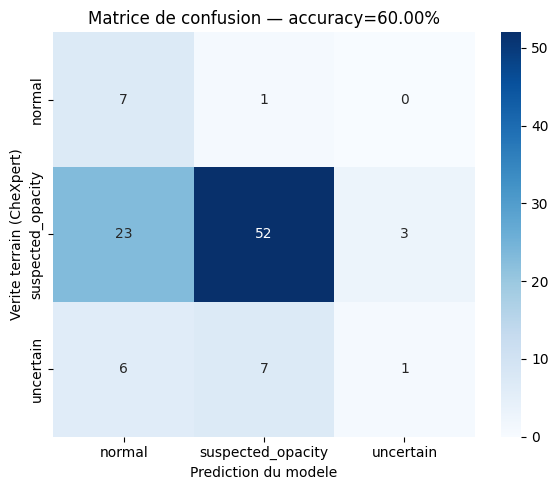

In [9]:
sample_100 = build_sample(100, seed=123)
results = evaluate_full(PROMPT_IMPROVED, sample_100, save_path="/kaggle/working/eval_results_improved.csv")


default case #1
[1/100] gt=suspected_opacity  pred=uncertain          conf=0.35  (19s ecoulees)
[2/100] gt=suspected_opacity  pred=suspected_opacity  conf=0.65  (37s ecoulees)
[3/100] gt=suspected_opacity  pred=normal             conf=0.85  (56s ecoulees)
[4/100] gt=normal             pred=normal             conf=0.95  (74s ecoulees)
[5/100] gt=suspected_opacity  pred=normal             conf=0.85  (93s ecoulees)
default case #1
[6/100] gt=suspected_opacity  pred=uncertain          conf=0.35  (111s ecoulees)
[7/100] gt=uncertain          pred=normal             conf=0.85  (130s ecoulees)
default case #1
[8/100] gt=suspected_opacity  pred=uncertain          conf=0.35  (149s ecoulees)
default case #1
[9/100] gt=suspected_opacity  pred=uncertain          conf=0.35  (167s ecoulees)
[10/100] gt=normal             pred=normal             conf=0.95  (186s ecoulees)
default case #1
[11/100] gt=suspected_opacity  pred=uncertain          conf=0.35  (205s ecoulees)
default case #1
[12/100] gt=susp

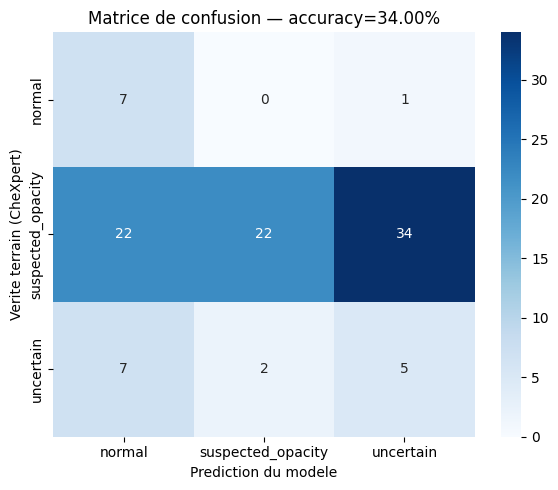

In [10]:
sample_100 = build_sample(100, seed=123)
results = evaluate_full(PROMPT_BASELINE, sample_100, save_path="/kaggle/working/eval_results_improved.csv")
